In [ ]:
!curl -s https://api.ipify.org
!pip install -q --upgrade joblib pandas numpy requests matplotlib scikit-learn xgboost tensorflow pyarrow fastparquet

In [ ]:
import json, joblib
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta
from time import sleep
from typing import Any
import warnings

from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import requests

from IPython.display import display
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import Input, Model, Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# API et Orchestration

In [ ]:
token = 'jGxAI6ytucdQs95Dwwtsmi4I24HuveuhmTyB02mIFZnQmQsdXLmtMw'
station = "ME098"
url = "https://www.infoclimat.fr/opendata/"
end_date = date.today()
start_date = end_date - timedelta(days=365)
chunk_days = 7
workers = 10
request_attempts = 3
request_pause = 0.4

In [ ]:
all_columns = [
    "station_id",
    "id_station",
    "dh_utc",
    "temperature",
    "pression",
    "pression_variation_3h",
    "humidite",
    "point_de_rosee",
    "visibilite",
    "vent_moyen",
    "vent_rafales",
    "vent_rafales_10min",
    "vent_direction",
    "temperature_min",
    "temperature_max",
    "pluie_1h",
    "pluie_3h",
    "pluie_6h",
    "pluie_12h",
    "pluie_24h",
    "pluie_cumul_0h",
    "pluie_intensite",
    "pluie_intensite_max_1h",
    "uv",
    "uv_index",
    "ensoleillement",
    "temperature_sol",
    "temps_omm",
    "complements",
    "source"
]
station_columns = [
    "station_name",
    "station_latitude",
    "station_longitude",
    "station_elevation",
    "license_source"
]
api_parameter_columns = [
    "temperature",
    "pression",
    "pression_variation_3h",
    "humidite",
    "point_de_rosee",
    "visibilite",
    "vent_moyen",
    "vent_rafales",
    "vent_rafales_10min",
    "vent_direction",
    "temperature_min",
    "temperature_max",
    "pluie_1h",
    "pluie_3h",
    "pluie_6h",
    "pluie_12h",
    "pluie_24h",
    "pluie_cumul_0h",
    "pluie_intensite",
    "pluie_intensite_max_1h",
    "uv",
    "uv_index",
    "ensoleillement",
    "temperature_sol",
    "temps_omm",
    "complements",
    "source"
]
api_parameter_groups = [
    [
        "temperature",
        "pression",
        "pression_variation_3h",
        "humidite",
        "point_de_rosee"
    ],
    [
        "visibilite",
        "vent_moyen",
        "vent_rafales",
        "vent_rafales_10min",
        "vent_direction"
    ],
    [
        "temperature_min",
        "temperature_max",
        "temps_omm",
        "complements",
        "source"
    ],
    [
        "pluie_1h",
        "pluie_3h",
        "pluie_6h",
        "pluie_12h",
        "pluie_24h",
        "pluie_cumul_0h",
        "pluie_intensite",
        "pluie_intensite_max_1h"
    ],
    [
        "uv",
        "uv_index",
        "ensoleillement",
        "temperature_sol"
    ]
]
alias_map = {
    "station_id": ["station_id", "id_station", "station", "id"],
    "id_station": ["id_station", "station_id", "station", "id"],
    "dh_utc": ["dh_utc", "date", "datetime", "time", "timestamp", "dh"],
    "pluie_1h": ["pluie_1h", "rain_1h", "precipitation_1h", "rr1", "rr_1h", "pluie1h"],
    "pluie_3h": ["pluie_3h", "rain_3h", "precipitation_3h", "rr3", "rr_3h", "pluie3h"],
    "pluie_6h": ["pluie_6h", "rain_6h", "precipitation_6h", "rr6", "rr_6h", "pluie6h"],
    "pluie_12h": ["pluie_12h", "rain_12h", "precipitation_12h", "rr12", "rr_12h", "pluie12h"],
    "pluie_24h": ["pluie_24h", "rain_24h", "precipitation_24h", "rr24", "rr_24h", "pluie24h"],
    "pluie_cumul_0h": ["pluie_cumul_0h", "pluie_cumul", "rain_cumul_0h", "precipitation_cumul_0h", "rr_cumul_0h"],
    "pluie_intensite": ["pluie_intensite", "rain_rate", "precipitation_intensity", "intensite_pluie"],
    "pluie_intensite_max_1h": ["pluie_intensite_max_1h", "rain_rate_max_1h", "precipitation_intensity_max_1h"]
}
text_columns = {
    "station_id",
    "id_station",
    "dh_utc",
    "source",
    "license_source",
    "station_name",
    "complements",
    "temps_omm"
}
rain_columns = {
    "pluie_1h",
    "pluie_3h",
    "pluie_6h",
    "pluie_12h",
    "pluie_24h",
    "pluie_cumul_0h",
    "pluie_intensite",
    "pluie_intensite_max_1h"
}
value_marker_keys = {
    "value",
    "valeur",
    "val",
    "v",
    "data",
    "measure",
    "mesure",
    "raw"
}
ignored_scalar_keys = {
    "source",
    "unit",
    "unite",
    "license",
    "licence",
    "quality",
    "qualite",
    "flag"
}
grouped_weather_keys = {
    "pluie",
    "rain",
    "precipitation",
    "rr",
    "vent",
    "wind"
}

def normalize_key(value: Any) -> str:
    return "".join(character for character in str(value).lower() if character.isalnum())

def build_alias_lookup() -> dict:
    lookup = {}
    for column in all_columns + station_columns:
        lookup[normalize_key(column)] = column
    for canonical_column, alternative_columns in alias_map.items():
        lookup[normalize_key(canonical_column)] = canonical_column
        for alternative_column in alternative_columns:
            lookup[normalize_key(alternative_column)] = canonical_column
    return lookup

alias_lookup = build_alias_lookup()


def has_value(value: Any) -> bool:
    if value is None:
        return False
    if value is pd.NA:
        return False
    if isinstance(value, str) and value.strip() == "":
        return False
    try:
        if pd.isna(value):
            return False
    except (TypeError, ValueError):
        return True
    return True


def normalize_scalar(value: Any) -> Any:
    if value is None:
        return pd.NA
    if value is pd.NA:
        return pd.NA
    if isinstance(value, dict) or isinstance(value, list):
        return json.dumps(value, ensure_ascii=False)
    if isinstance(value, str):
        clean_value = value.strip()
        if clean_value.lower() in {"", "null", "none", "nan", "na", "n/a", "-"}:
            return pd.NA
        clean_value = clean_value.replace(",", ".")
        clean_value = clean_value.replace("−", "-")
        return clean_value
    return value

def canonical_from_key(key: Any) -> str | None:
    return alias_lookup.get(normalize_key(key))

def canonical_from_path(path: list[Any]) -> str | None:
    parts = [normalize_key(part) for part in path]
    parts = [part for part in parts if part]
    if not parts:
        return None
    candidates = [parts[-1]]
    if len(parts) >= 2:
        candidates.append("".join(parts[-2:]))
    if len(parts) >= 3:
        candidates.append("".join(parts[-3:]))
    parts_without_markers = [
        part for part in parts
        if part not in value_marker_keys
    ]
    if parts_without_markers:
        candidates.append(parts_without_markers[-1])
    if len(parts_without_markers) >= 2:
        candidates.append("".join(parts_without_markers[-2:]))
    if len(parts_without_markers) >= 3:
        candidates.append("".join(parts_without_markers[-3:]))
    candidates.append("".join(parts))
    candidates.append("".join(parts_without_markers))
    for candidate in candidates:
        if candidate in alias_lookup:
            return alias_lookup[candidate]
    return None

def extract_best_scalar(value: Any) -> Any:
    if not isinstance(value, dict) and not isinstance(value, list):
        return value
    if isinstance(value, list):
        for item in value:
            scalar = extract_best_scalar(item)
            if has_value(scalar):
                return scalar
        return pd.NA
    normalized_items = {
        normalize_key(key): item
        for key, item in value.items()
    }
    for marker in value_marker_keys:
        if marker in normalized_items:
            scalar = extract_best_scalar(normalized_items[marker])
            if has_value(scalar):
                return scalar
    for key, item in value.items():
        if normalize_key(key) in ignored_scalar_keys:
            continue
        if not isinstance(item, dict) and not isinstance(item, list):
            if has_value(item):
                return item
    for item in value.values():
        scalar = extract_best_scalar(item)
        if has_value(scalar):
            return scalar
    return pd.NA

def assign_record_value(record: dict, column: str | None, value: Any) -> None:
    if column is None:
        return
    if column not in all_columns and column not in station_columns:
        return
    if not has_value(value):
        return
    if not has_value(record.get(column)):
        record[column] = value

def collect_record_values(node: Any, path: list[Any], record: dict) -> None:
    if isinstance(node, dict):
        for raw_key, raw_value in node.items():
            if str(raw_key).startswith("_"):
                continue
            next_path = path + [raw_key]
            direct_column = canonical_from_key(raw_key)
            path_column = canonical_from_path(next_path)
            column = direct_column or path_column
            if column:
                assign_record_value(record, column, extract_best_scalar(raw_value))
            collect_record_values(raw_value, next_path, record)
    elif isinstance(node, list):
        for item in node:
            collect_record_values(item, path, record)
    else:
        column = canonical_from_path(path)
        assign_record_value(record, column, node)

def looks_like_datetime(value: Any) -> bool:
    if not isinstance(value, str):
        return False
    text_value = value.strip()
    if len(text_value) < 8:
        return False
    parsed_value = pd.to_datetime(text_value, errors="coerce", utc=True)
    return not pd.isna(parsed_value)

def is_measure_record(value: Any) -> bool:
    if not isinstance(value, dict):
        return False
    for raw_key in value.keys():
        if canonical_from_key(raw_key):
            return True
        if normalize_key(raw_key) in grouped_weather_keys:
            return True
    return False

def apply_aliases(record: dict) -> dict:
    for canonical_column, alternative_columns in alias_map.items():
        if has_value(record.get(canonical_column)):
            continue
        for alternative_column in alternative_columns:
            if has_value(record.get(alternative_column)):
                record[canonical_column] = record.get(alternative_column)
                break
    return record

def parse_json_record(record: dict, station_identifier: Any = None, timestamp: Any = None) -> dict:
    parsed_record = {}
    collect_record_values(record, [], parsed_record)
    if not has_value(parsed_record.get("station_id")):
        parsed_record["station_id"] = station_identifier or station
    if not has_value(parsed_record.get("id_station")):
        parsed_record["id_station"] = parsed_record.get("station_id")
    if not has_value(parsed_record.get("dh_utc")) and looks_like_datetime(timestamp):
        parsed_record["dh_utc"] = timestamp
    parsed_record = apply_aliases(parsed_record)
    return parsed_record

def parse_station_records(station_identifier: Any, station_records: Any, timestamp: Any = None) -> list[dict]:
    parsed_records = []
    if isinstance(station_records, list):
        for station_record in station_records:
            if isinstance(station_record, dict):
                if is_measure_record(station_record):
                    parsed_records.append(
                        parse_json_record(station_record, station_identifier, timestamp)
                    )
                else:
                    parsed_records.extend(
                        parse_station_records(station_identifier, station_record, timestamp)
                    )
        return parsed_records
    if isinstance(station_records, dict):
        if is_measure_record(station_records):
            parsed_records.append(
                parse_json_record(station_records, station_identifier, timestamp)
            )
            return parsed_records
        for record_key, record_value in station_records.items():
            if str(record_key).startswith("_"):
                continue
            next_station = station_identifier
            next_timestamp = timestamp
            if looks_like_datetime(record_key):
                next_timestamp = record_key
            elif isinstance(record_value, dict) or isinstance(record_value, list):
                next_station = record_key
            parsed_records.extend(
                parse_station_records(next_station, record_value, next_timestamp)
            )
    return parsed_records

def extract_from_hourly(result: dict) -> list[dict]:
    hourly_data = result.get("hourly", {})
    records = []
    if isinstance(hourly_data, list):
        return parse_station_records(station, hourly_data)
    if not isinstance(hourly_data, dict):
        return records
    if is_measure_record(hourly_data):
        return parse_station_records(station, hourly_data)
    for station_identifier, station_records in hourly_data.items():
        if str(station_identifier).startswith("_"):
            continue
        records.extend(parse_station_records(station_identifier, station_records))

    return records

def extract_from_data(result: dict) -> list[dict]:
    data_records = result.get("data", [])
    return parse_station_records(station, data_records)

def extract_hourly_records(result: dict) -> list[dict]:
    records = extract_from_hourly(result)
    if records:
        return records
    return extract_from_data(result)

def build_station_lookup(result: dict) -> dict:
    stations = result.get("stations", [])
    station_lookup = {}

    if isinstance(stations, list):
        for station_record in stations:
            if not isinstance(station_record, dict):
                continue
            station_identifier = (
                station_record.get("id")
                or station_record.get("id_station")
                or station_record.get("station_id")
            )
            if station_identifier:
                station_lookup[str(station_identifier)] = station_record
    if isinstance(stations, dict):
        for station_identifier, station_record in stations.items():
            if isinstance(station_record, dict):
                station_lookup[str(station_identifier)] = station_record
    return station_lookup

def get_station_source(station_record: dict) -> Any:
    license_data = station_record.get("license", {})
    if isinstance(license_data, dict):
        return license_data.get("source", pd.NA)
    return pd.NA

def get_station_metadata(station_lookup: dict, station_identifier: Any, key: str) -> Any:
    if not has_value(station_identifier):
        return pd.NA
    station_record = station_lookup.get(str(station_identifier), {})
    if not isinstance(station_record, dict):
        return pd.NA
    return station_record.get(key, pd.NA)


def add_station_metadata(df: pd.DataFrame, station_lookup: dict) -> pd.DataFrame:
    if "station_id" not in df.columns:
        df["station_id"] = station
    df["station_name"] = df["station_id"].map(
        lambda station_identifier: get_station_metadata(station_lookup, station_identifier, "name")
    )
    df["station_latitude"] = df["station_id"].map(
        lambda station_identifier: get_station_metadata(station_lookup, station_identifier, "latitude")
    )
    df["station_longitude"] = df["station_id"].map(
        lambda station_identifier: get_station_metadata(station_lookup, station_identifier, "longitude")
    )
    df["station_elevation"] = df["station_id"].map(
        lambda station_identifier: get_station_metadata(station_lookup, station_identifier, "elevation")
    )
    df["license_source"] = df["station_id"].map(
        lambda station_identifier: get_station_source(
            station_lookup.get(str(station_identifier), {})
        )
    )
    return df

def ensure_expected_columns(df: pd.DataFrame) -> pd.DataFrame:
    expected_columns = all_columns + station_columns
    for column in expected_columns:
        if column not in df.columns:
            df[column] = pd.NA

    extra_columns = [
        column for column in df.columns
        if column not in expected_columns
    ]
    return df[expected_columns + extra_columns]

def clean_weather_types(df: pd.DataFrame) -> pd.DataFrame:
    for column in df.columns:
        df[column] = df[column].map(normalize_scalar)
    if "dh_utc" in df.columns:
        df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)
    for column in df.columns:
        if column in text_columns:
            continue

        string_values = (
            df[column]
            .astype("string")
            .str.strip()
            .str.replace(",", ".", regex=False)
            .str.replace("−", "-", regex=False)
        )
        numeric_values = string_values.str.extract(r"([-+]?\d*\.?\d+)", expand=False)
        df[column] = pd.to_numeric(numeric_values, errors="coerce")
        if column in rain_columns:
            zero_values = string_values.str.lower().isin({
                "0",
                "0.0",
                "0.00",
                "+0",
                "+0.0",
                "+0.00"
            })
            df.loc[zero_values.fillna(False), column] = 0.0

    return df

def fix_source_column(df: pd.DataFrame) -> pd.DataFrame:
    if "source" not in df.columns:
        df["source"] = pd.NA

    if "license_source" not in df.columns:
        df["license_source"] = pd.NA

    df["source"] = df["source"].replace("", pd.NA)
    df["source"] = df["source"].fillna(df["license_source"])

    return df

def convert_hourly_to_dataframe(result: dict) -> pd.DataFrame:
    station_lookup = build_station_lookup(result)
    records = extract_hourly_records(result)
    df = pd.DataFrame(records)

    if df.empty:
        return df
    df = add_station_metadata(df, station_lookup)
    df = fix_source_column(df)
    df = ensure_expected_columns(df)
    df = clean_weather_types(df)
    return df

def validate_response_text(response: requests.Response) -> None:
    response_text = response.text.strip()
    if response_text.lower().startswith("wrong ip"):
        raise ValueError("Wrong IP address. Regenerate your Infoclimat token using the current public IP.")
    if response_text.startswith("<"):
        raise ValueError(response_text[:500])

def build_request_parameters(chunk_start: date, chunk_end: date, parameter_columns: list[str] | None = None) -> list[tuple[str, str]]:
    if not token:
        raise ValueError("Set INFOCLIMAT_TOKEN before running this script.")
    selected_columns = parameter_columns or api_parameter_columns
    request_parameters = [
        ("method", "get"),
        ("format", "json"),
        ("start", chunk_start.isoformat()),
        ("end", chunk_end.isoformat()),
        ("token", token),
        ("stations[]", station)
    ]
    for column in selected_columns:
        request_parameters.append(("params[]", column))
    return request_parameters

def request_weather_json(chunk_start: date, chunk_end: date, parameter_columns: list[str]) -> dict:
    last_error = None
    for attempt in range(request_attempts):
        try:
            request_parameters = build_request_parameters(
                chunk_start,
                chunk_end,
                parameter_columns
            )
            response = requests.get(url, params=request_parameters, timeout=30)
            validate_response_text(response)
            response.raise_for_status()
            result = response.json()
            if result.get("status") != "OK":
                raise ValueError(result)
            if result.get("errors"):
                raise ValueError(result.get("errors"))
            return result
        except Exception as error:
            last_error = error
            if attempt == request_attempts - 1:
                break
            sleep(request_pause * (attempt + 1))
    raise RuntimeError(f"Failed request from {chunk_start} to {chunk_end}: {last_error}")

def merge_parameter_frames(left_frame: pd.DataFrame, right_frame: pd.DataFrame) -> pd.DataFrame:
    if left_frame.empty:
        return right_frame
    if right_frame.empty:
        return left_frame
    merge_keys = ["station_id", "dh_utc"]
    if any(column not in left_frame.columns for column in merge_keys):
        return left_frame
    if any(column not in right_frame.columns for column in merge_keys):
        return left_frame
    left_frame = left_frame.drop_duplicates(subset=merge_keys)
    right_frame = right_frame.drop_duplicates(subset=merge_keys)
    merged_frame = left_frame.merge(
        right_frame,
        on=merge_keys,
        how="outer",
        suffixes=("", "_api")
    )
    for column in list(merged_frame.columns):
        if not column.endswith("_api"):
            continue
        original_column = column[:-4]
        if original_column in merged_frame.columns:
            merged_frame[original_column] = (
                merged_frame[column]
                .combine_first(merged_frame[original_column])
            )
            merged_frame = merged_frame.drop(columns=[column])
        else:
            merged_frame = merged_frame.rename(columns={column: original_column})
    return merged_frame

def fetch_weather_chunk(chunk_start: date, chunk_end: date) -> pd.DataFrame:
    chunk_frame = pd.DataFrame()
    for parameter_group in api_parameter_groups:
        result = request_weather_json(chunk_start, chunk_end, parameter_group)
        group_frame = convert_hourly_to_dataframe(result)
        chunk_frame = merge_parameter_frames(chunk_frame, group_frame)
    if chunk_frame.empty:
        return chunk_frame
    chunk_frame = ensure_expected_columns(chunk_frame)
    chunk_frame = clean_weather_types(chunk_frame)
    return chunk_frame

def fetch_raw_weather_chunk(chunk_start: date, chunk_end: date, parameter_columns: list[str] | None = None) -> dict:
    selected_columns = parameter_columns or api_parameter_columns
    return request_weather_json(chunk_start, chunk_end, selected_columns)

def collect_raw_paths(node: Any, path: list[str] | None = None, paths: set[str] | None = None) -> set[str]:
    if path is None:
        path = []
    if paths is None:
        paths = set()
    if isinstance(node, dict):
        for key, value in node.items():
            next_path = path + [str(key)]
            paths.add(".".join(next_path))
            collect_raw_paths(value, next_path, paths)
    elif isinstance(node, list):
        for item in node:
            collect_raw_paths(item, path, paths)
    return paths

def debug_weather_chunk(chunk_start: date, chunk_end: date) -> dict:
    result = fetch_raw_weather_chunk(chunk_start, chunk_end)
    records = extract_hourly_records(result)
    raw_paths = sorted(collect_raw_paths(result))
    parsed_keys = sorted({key for record in records for key in record.keys()})
    returned_parameters = result.get("hourly", {}).get("_params", [])
    print("Returned parameters:")
    print(returned_parameters)
    print("Parsed keys:")
    print(parsed_keys)
    print("Raw paths containing rain:")
    print([
        path for path in raw_paths
        if "pluie" in path.lower()
        or "rain" in path.lower()
        or "rr" in path.lower()
        or "precip" in path.lower()
    ])
    print("Parsed rain keys:")
    print([
        key for key in parsed_keys
        if "pluie" in key
        or "rain" in key
        or "rr" in key
    ])
    return result

def build_date_chunks(first_date: date, last_date: date) -> list[tuple[date, date]]:
    chunks = []
    current_start = first_date
    while current_start <= last_date:
        current_end = min(
            current_start + timedelta(days=chunk_days - 1),
            last_date
        )
        chunks.append((current_start, current_end))
        current_start = current_end + timedelta(days=1)
    return chunks

def finalize_weather_dataframe(frames: list[pd.DataFrame]) -> pd.DataFrame:
    if not frames:
        return pd.DataFrame(columns=all_columns + station_columns)
    df = pd.concat(frames, ignore_index=True)
    df = ensure_expected_columns(df)
    df = clean_weather_types(df)
    if "station_id" in df.columns and "dh_utc" in df.columns:
        df = df.drop_duplicates(subset=["station_id", "dh_utc"])
        df = df.sort_values(["station_id", "dh_utc"]).reset_index(drop=True)
    return df

def fetch_weather_dataframe(start_date: date, end_date: date, workers: int = 4) -> pd.DataFrame:
    chunks = build_date_chunks(start_date, end_date)
    frames = []
    with ThreadPoolExecutor(max_workers=workers) as executor:
        future_map = {
            executor.submit(fetch_weather_chunk, chunk_start, chunk_end): (chunk_start, chunk_end)
            for chunk_start, chunk_end in chunks
        }
        for future in as_completed(future_map):
            chunk_start, chunk_end = future_map[future]
            try:
                chunk_frame = future.result()
                print(f"Fetched {chunk_start} to {chunk_end}: {len(chunk_frame)} rows")
                if not chunk_frame.empty:
                    frames.append(chunk_frame)
            except Exception as error:
                print(f"Failed {chunk_start} to {chunk_end}: {error}")
                raise
    return finalize_weather_dataframe(frames)

In [5]:
df = fetch_weather_dataframe(start_date, end_date, workers=workers)

Fetched 2025-10-07 to 2025-10-13: 1004 rows
Fetched 2025-11-18 to 2025-11-24: 404 rows
Fetched 2025-09-30 to 2025-10-06: 1006 rows
Fetched 2025-10-14 to 2025-10-20: 908 rows
Fetched 2025-10-21 to 2025-10-27: 985 rows
Fetched 2025-10-28 to 2025-11-03: 994 rows
Fetched 2025-11-11 to 2025-11-17: 982 rows
Fetched 2025-11-04 to 2025-11-10: 996 rows
Fetched 2025-12-02 to 2025-12-08: 997 rows
Fetched 2025-11-25 to 2025-12-01: 967 rows
Fetched 2025-12-23 to 2025-12-29: 980 rows
Fetched 2025-12-09 to 2025-12-15: 999 rows
Fetched 2025-12-16 to 2025-12-22: 997 rows
Fetched 2026-01-06 to 2026-01-12: 994 rows
Fetched 2026-01-13 to 2026-01-19: 998 rows
Fetched 2025-12-30 to 2026-01-05: 999 rows
Fetched 2026-01-20 to 2026-01-26: 997 rows
Fetched 2026-01-27 to 2026-02-02: 1001 rows
Fetched 2026-02-03 to 2026-02-09: 999 rows
Fetched 2026-02-10 to 2026-02-16: 998 rows
Fetched 2026-03-24 to 2026-03-30: 1000 rows
Fetched 2026-02-24 to 2026-03-02: 1000 rows
Fetched 2026-02-17 to 2026-02-23: 991 rows
Fetche

In [6]:
df.head()

,station_id,id_station,dh_utc,temperature,pression,pression_variation_3h,humidite,point_de_rosee,visibilite,vent_moyen,vent_rafales,vent_rafales_10min,vent_direction,temperature_min,temperature_max,pluie_1h,pluie_3h,pluie_6h,pluie_12h,pluie_24h,pluie_cumul_0h,pluie_intensite,pluie_intensite_max_1h,uv,uv_index,ensoleillement,temperature_sol,temps_omm,complements,source,station_name,station_latitude,station_longitude,station_elevation,license_source
0,ME098,ME098,2025-05-13 00:00:00+00:00,14.6,1010.2,<NA>,79.0,11.1,<NA>,0.0,<NA>,<NA>,150.0,<NA>,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
1,ME098,ME098,2025-05-13 00:10:00+00:00,14.4,1010.3,<NA>,80.0,11.1,<NA>,0.0,<NA>,<NA>,150.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
2,ME098,ME098,2025-05-13 00:20:00+00:00,14.3,1010.4,<NA>,79.0,10.6,<NA>,0.0,<NA>,<NA>,150.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
3,ME098,ME098,2025-05-13 00:30:00+00:00,14.1,1010.3,<NA>,80.0,10.6,<NA>,0.0,<NA>,<NA>,150.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
4,ME098,ME098,2025-05-13 00:40:00+00:00,14.1,1010.4,<NA>,81.0,11.1,<NA>,0.0,<NA>,<NA>,150.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr


In [7]:
print(df.shape)

(51284, 35)


In [8]:
df.isnull().sum()

station_id                    0
id_station                    0
dh_utc                        0
temperature                3860
pression                      0
pression_variation_3h     51284
humidite                   3875
point_de_rosee             3876
visibilite                51284
vent_moyen                 4308
vent_rafales              51284
vent_rafales_10min        51284
vent_direction             3855
temperature_min           51284
temperature_max           51284
pluie_1h                  42809
pluie_3h                  50578
pluie_6h                  51284
pluie_12h                 51284
pluie_24h                 51284
pluie_cumul_0h            51284
pluie_intensite           51284
pluie_intensite_max_1h    51284
uv                        51284
uv_index                  51284
ensoleillement            51284
temperature_sol           51284
temps_omm                 51284
complements               51284
source                        0
station_name                  0
station_

In [9]:
df.columns

Index(['station_id', 'id_station', 'dh_utc', 'temperature', 'pression',
       'pression_variation_3h', 'humidite', 'point_de_rosee', 'visibilite',
       'vent_moyen', 'vent_rafales', 'vent_rafales_10min', 'vent_direction',
       'temperature_min', 'temperature_max', 'pluie_1h', 'pluie_3h',
       'pluie_6h', 'pluie_12h', 'pluie_24h', 'pluie_cumul_0h',
       'pluie_intensite', 'pluie_intensite_max_1h', 'uv', 'uv_index',
       'ensoleillement', 'temperature_sol', 'temps_omm', 'complements',
       'source', 'station_name', 'station_latitude', 'station_longitude',
       'station_elevation', 'license_source'],
      dtype='str')

# Sauvegarde et Base de Donnees

In [10]:
project_folder = Path.cwd() / "projet_goutte_eau"
project_folder.mkdir(parents=True, exist_ok=True)

parquet_path = project_folder / "weather_raw.parquet"
csv_path = project_folder / "weather_raw.csv"

df.to_parquet(parquet_path, index=False)
df.to_csv(csv_path, index=False)

print(parquet_path.resolve())
print(csv_path.resolve())


/workspaces/GoutteEau/projet_goutte_eau/weather_raw.parquet
/workspaces/GoutteEau/projet_goutte_eau/weather_raw.csv


In [11]:
import sqlite3

project_folder = Path.cwd() / "projet_goutte_eau"
project_folder.mkdir(parents=True, exist_ok=True)

database_path = project_folder / "weather_database.sqlite"
database_connection = sqlite3.connect(database_path)

database_frame = df.copy()
database_frame["dh_utc"] = database_frame["dh_utc"].astype(str)

database_frame.to_sql(
    name="weather_raw",
    con=database_connection,
    if_exists="replace",
    index=False
)

database_connection.close()

print(database_path.resolve())


/workspaces/GoutteEau/projet_goutte_eau/weather_database.sqlite


In [12]:
database_connection = sqlite3.connect(database_path)
test_frame = pd.read_sql_query(
    "SELECT * FROM weather_raw LIMIT 5",
    database_connection
)
database_connection.close()

test_frame

,station_id,id_station,dh_utc,temperature,pression,pression_variation_3h,humidite,point_de_rosee,visibilite,vent_moyen,vent_rafales,vent_rafales_10min,vent_direction,temperature_min,temperature_max,pluie_1h,pluie_3h,pluie_6h,pluie_12h,pluie_24h,pluie_cumul_0h,pluie_intensite,pluie_intensite_max_1h,uv,uv_index,ensoleillement,temperature_sol,temps_omm,complements,source,station_name,station_latitude,station_longitude,station_elevation,license_source
0,ME098,ME098,2025-05-13 00:00:00+00:00,14.6,1010.2,None,79.0,11.1,None,0.0,None,None,150.0,None,None,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
1,ME098,ME098,2025-05-13 00:10:00+00:00,14.4,1010.3,None,80.0,11.1,None,0.0,None,None,150.0,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
2,ME098,ME098,2025-05-13 00:20:00+00:00,14.3,1010.4,None,79.0,10.6,None,0.0,None,None,150.0,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
3,ME098,ME098,2025-05-13 00:30:00+00:00,14.1,1010.3,None,80.0,10.6,None,0.0,None,None,150.0,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr
4,ME098,ME098,2025-05-13 00:40:00+00:00,14.1,1010.4,None,81.0,11.1,None,0.0,None,None,150.0,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,infoclimat.fr,[MAE] ESPE - PARIS,48.846,2.267,36,infoclimat.fr


# Nettoyage et Seperation

In [13]:
selected_columns = [
    "station_id",
    "dh_utc",
    "temperature",
    "pression",
    "humidite",
    "point_de_rosee",
    "vent_moyen",
    "vent_direction",
    "station_latitude",
    "station_longitude",
    "station_elevation",
    "pluie_1h"
]
rain_frame = df[selected_columns].copy()
rain_frame = rain_frame.dropna(subset=["pluie_1h"])
rain_frame["dh_utc"] = pd.to_datetime(
    rain_frame["dh_utc"],
    errors="coerce",
    utc=True
)
rain_frame = rain_frame.dropna(subset=["dh_utc"])
rain_frame = rain_frame.sort_values("dh_utc").reset_index(drop=True)

rain_frame

,station_id,dh_utc,temperature,pression,humidite,point_de_rosee,vent_moyen,vent_direction,station_latitude,station_longitude,station_elevation,pluie_1h
0,ME098,2025-05-13 00:00:00+00:00,14.6,1010.2,79.0,11.1,0.0,150.0,48.846,2.267,36,0.0
1,ME098,2025-05-13 01:00:00+00:00,13.9,1010.5,82.0,11.1,0.0,150.0,48.846,2.267,36,0.0
2,ME098,2025-05-13 02:00:00+00:00,13.3,1010.8,83.0,10.6,0.0,150.0,48.846,2.267,36,0.0
3,ME098,2025-05-13 03:00:00+00:00,13.1,1011.1,86.0,10.6,0.0,150.0,48.846,2.267,36,0.0
4,ME098,2025-05-13 04:00:00+00:00,12.6,1011.3,86.0,10.6,0.0,150.0,48.846,2.267,36,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8470,ME098,2026-05-13 10:00:00+00:00,14.9,1003.6,60.0,7.2,0.0,142.0,48.846,2.267,36,0.0
8471,ME098,2026-05-13 11:00:00+00:00,14.2,1002.7,59.0,6.1,0.0,142.0,48.846,2.267,36,0.0
8472,ME098,2026-05-13 12:00:00+00:00,14.0,1002.8,70.0,8.3,0.0,142.0,48.846,2.267,36,0.0
8473,ME098,2026-05-13 13:00:00+00:00,15.4,1001.9,70.0,10.0,0.0,142.0,48.846,2.267,36,0.0


In [14]:
model_columns = [
    "temperature",
    "pression",
    "humidite",
    "point_de_rosee",
    "vent_moyen",
    "vent_direction",
    "station_latitude",
    "station_longitude",
    "station_elevation",
    "pluie_1h"
]

rain_frame_clean = rain_frame.dropna(subset=model_columns).reset_index(drop=True)

rain_frame_clean

,station_id,dh_utc,temperature,pression,humidite,point_de_rosee,vent_moyen,vent_direction,station_latitude,station_longitude,station_elevation,pluie_1h
0,ME098,2025-05-13 00:00:00+00:00,14.6,1010.2,79.0,11.1,0.0,150.0,48.846,2.267,36,0.0
1,ME098,2025-05-13 01:00:00+00:00,13.9,1010.5,82.0,11.1,0.0,150.0,48.846,2.267,36,0.0
2,ME098,2025-05-13 02:00:00+00:00,13.3,1010.8,83.0,10.6,0.0,150.0,48.846,2.267,36,0.0
3,ME098,2025-05-13 03:00:00+00:00,13.1,1011.1,86.0,10.6,0.0,150.0,48.846,2.267,36,0.0
4,ME098,2025-05-13 04:00:00+00:00,12.6,1011.3,86.0,10.6,0.0,150.0,48.846,2.267,36,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7757,ME098,2026-05-13 10:00:00+00:00,14.9,1003.6,60.0,7.2,0.0,142.0,48.846,2.267,36,0.0
7758,ME098,2026-05-13 11:00:00+00:00,14.2,1002.7,59.0,6.1,0.0,142.0,48.846,2.267,36,0.0
7759,ME098,2026-05-13 12:00:00+00:00,14.0,1002.8,70.0,8.3,0.0,142.0,48.846,2.267,36,0.0
7760,ME098,2026-05-13 13:00:00+00:00,15.4,1001.9,70.0,10.0,0.0,142.0,48.846,2.267,36,0.0


In [15]:
rain_frame_clean = rain_frame_clean.copy()

rain_frame_clean["rain_risk"] = (
    rain_frame_clean["pluie_1h"] > 0
).astype(int)

rain_frame_clean["hour"] = rain_frame_clean["dh_utc"].dt.hour
rain_frame_clean["day_of_week"] = rain_frame_clean["dh_utc"].dt.dayofweek
rain_frame_clean["month"] = rain_frame_clean["dh_utc"].dt.month

rain_frame_clean[["dh_utc", "pluie_1h", "rain_risk", "hour", "day_of_week", "month"]].head()

,dh_utc,pluie_1h,rain_risk,hour,day_of_week,month
0,2025-05-13 00:00:00+00:00,0.0,0,0,1,5
1,2025-05-13 01:00:00+00:00,0.0,0,1,1,5
2,2025-05-13 02:00:00+00:00,0.0,0,2,1,5
3,2025-05-13 03:00:00+00:00,0.0,0,3,1,5
4,2025-05-13 04:00:00+00:00,0.0,0,4,1,5


In [16]:
def split_train_test(dataframe, target_column="rain_risk", test_size=0.2):
    dataframe = dataframe.copy()
    dataframe = dataframe.sort_values("dh_utc").reset_index(drop=True)
    feature_columns = [
        "temperature",
        "pression",
        "humidite",
        "point_de_rosee",
        "vent_moyen",
        "vent_direction",
        "station_latitude",
        "station_longitude",
        "station_elevation",
        "hour",
        "day_of_week",
        "month"
    ]
    split_index = int(len(dataframe) * (1 - test_size))
    train_frame = dataframe.iloc[:split_index].copy()
    test_frame = dataframe.iloc[split_index:].copy()
    Xtrain = train_frame[feature_columns]
    Xtest = test_frame[feature_columns]
    ytrain = train_frame[target_column]
    ytest = test_frame[target_column]
    return Xtrain, Xtest, ytrain, ytest

In [17]:
Xtrain, Xtest, ytrain, ytest = split_train_test(rain_frame_clean)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(6209, 12)
(1553, 12)
(6209,)
(1553,)


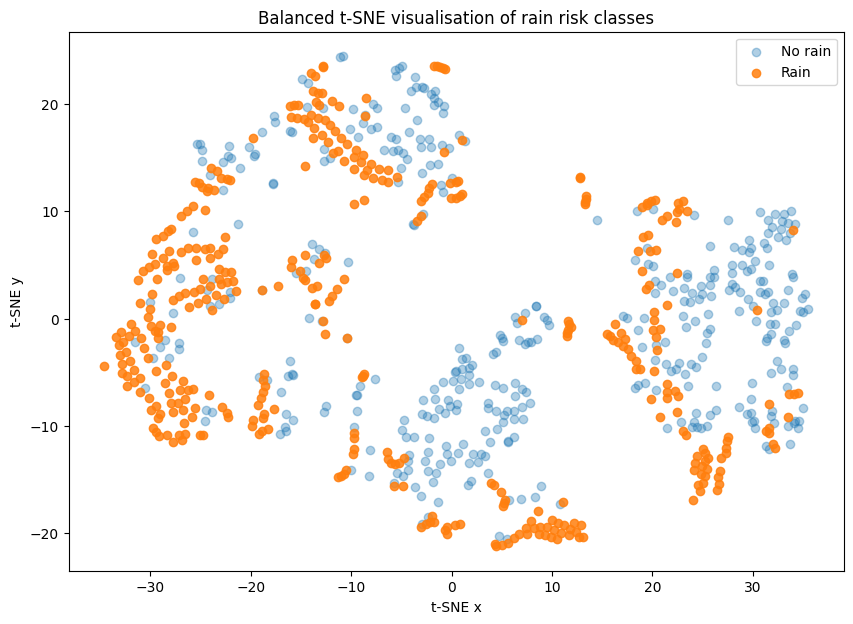

In [18]:

base_frame = rain_frame_clean.copy()
base_frame = base_frame.loc[:, ~base_frame.columns.duplicated()].copy()

selected_columns = [
    "temperature",
    "pression",
    "humidite",
    "point_de_rosee",
    "vent_moyen",
    "vent_direction",
    "station_latitude",
    "station_longitude",
    "station_elevation"
]

required_columns = selected_columns + ["dh_utc", "pluie_1h", "rain_risk"]

tsne_frame = base_frame[required_columns].copy()
tsne_frame = tsne_frame.loc[:, ~tsne_frame.columns.duplicated()].copy()

for column in selected_columns:
    tsne_frame[column] = pd.to_numeric(tsne_frame[column], errors="coerce")

tsne_frame["rain_risk"] = pd.to_numeric(tsne_frame["rain_risk"], errors="coerce")
tsne_frame["dh_utc"] = pd.to_datetime(tsne_frame["dh_utc"], errors="coerce", utc=True)

tsne_frame["hour"] = tsne_frame["dh_utc"].dt.hour
tsne_frame["month"] = tsne_frame["dh_utc"].dt.month

tsne_frame["hour_sin"] = np.sin(2 * np.pi * tsne_frame["hour"] / 24)
tsne_frame["hour_cos"] = np.cos(2 * np.pi * tsne_frame["hour"] / 24)

tsne_frame["month_sin"] = np.sin(2 * np.pi * tsne_frame["month"] / 12)
tsne_frame["month_cos"] = np.cos(2 * np.pi * tsne_frame["month"] / 12)

model_columns = selected_columns + [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

tsne_frame = tsne_frame.dropna(subset=model_columns + ["rain_risk"]).copy()
tsne_frame["rain_risk"] = tsne_frame["rain_risk"].astype(int)

no_rain_frame = tsne_frame[tsne_frame["rain_risk"] == 0]
rain_frame = tsne_frame[tsne_frame["rain_risk"] == 1]

sample_size = min(len(no_rain_frame), len(rain_frame), 2500)

no_rain_sample = no_rain_frame.sample(
    n=sample_size,
    random_state=42
)

rain_sample = rain_frame.sample(
    n=sample_size,
    random_state=42
)

tsne_frame = pd.concat(
    [no_rain_sample, rain_sample],
    ignore_index=True
)

features = tsne_frame[model_columns]
target = tsne_frame["rain_risk"]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

tsne_model = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_values = tsne_model.fit_transform(features_scaled)

tsne_frame["tsne_x"] = tsne_values[:, 0]
tsne_frame["tsne_y"] = tsne_values[:, 1]

plt.figure(figsize=(10, 7))

plt.scatter(
    tsne_frame.loc[tsne_frame["rain_risk"] == 0, "tsne_x"],
    tsne_frame.loc[tsne_frame["rain_risk"] == 0, "tsne_y"],
    alpha=0.35,
    label="No rain"
)

plt.scatter(
    tsne_frame.loc[tsne_frame["rain_risk"] == 1, "tsne_x"],
    tsne_frame.loc[tsne_frame["rain_risk"] == 1, "tsne_y"],
    alpha=0.85,
    label="Rain"
)

plt.xlabel("t-SNE x")
plt.ylabel("t-SNE y")
plt.title("Balanced t-SNE visualisation of rain risk classes")
plt.legend()
plt.show()

# Modeles et Evaluation

In [19]:
save_folder = Path.cwd() / "goutte_eau_project"
save_folder.mkdir(parents=True, exist_ok=True)
rain_feature_columns = [
    "temperature",
    "pression",
    "humidite",
    "point_de_rosee",
    "vent_moyen",
    "vent_direction",
    "station_latitude",
    "station_longitude",
    "station_elevation",
    "hour",
    "month",
    "day_of_year"
]
rain_target_column = "rain_risk"
rain_amount_column = "pluie_1h"

def add_time_features(input_frame):
    frame = input_frame.copy()
    if "dh_utc" in frame.columns:
        date_values = pd.to_datetime(frame["dh_utc"], errors="coerce", utc=True)
        frame["hour"] = date_values.dt.hour
        frame["month"] = date_values.dt.month
        frame["day_of_year"] = date_values.dt.dayofyear
    else:
        frame["hour"] = np.nan
        frame["month"] = np.nan
        frame["day_of_year"] = np.nan
    return frame

def add_rain_target(input_frame):
    frame = input_frame.copy()
    if rain_target_column in frame.columns:
        target_values = pd.to_numeric(frame[rain_target_column], errors="coerce")
        frame[rain_target_column] = target_values
        return frame
    if rain_amount_column not in frame.columns:
        raise ValueError("pluie_1h is required to create rain_risk.")
    rain_text_values = (
        frame[rain_amount_column]
        .astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
        .str.replace("−", "-", regex=False)
    )
    rain_values = pd.to_numeric(rain_text_values, errors="coerce")
    rain_target = pd.Series(np.nan, index=frame.index, dtype="float64")
    valid_rows = rain_values.notna()
    rain_target.loc[valid_rows] = rain_values.loc[valid_rows].gt(0).astype(int)
    frame[rain_target_column] = rain_target
    return frame

def prepare_rain_training_frame(input_frame):
    frame = add_time_features(input_frame)
    frame = add_rain_target(frame)
    for column in rain_feature_columns:
        if column not in frame.columns:
            frame[column] = np.nan
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=[rain_target_column]).copy()
    frame = frame[~frame[rain_feature_columns].isna().all(axis=1)].copy()
    frame[rain_target_column] = frame[rain_target_column].astype(int)
    if frame[rain_target_column].nunique() < 2:
        raise ValueError("The target has only one class. You need both rain and no-rain rows.")
    return frame


In [20]:
def build_lstm_dropout_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.30),
        LSTM(32),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy")
    return model


def build_attention_bilstm(input_shape):
    inputs = Input(shape=input_shape)
    sequence_values = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    attention_values = Attention()([sequence_values, sequence_values])
    pooled_values = GlobalAveragePooling1D()(attention_values)
    dense_values = Dense(32, activation="relu")(pooled_values)
    outputs = Dense(1, activation="sigmoid")(dense_values)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy")
    return model


def build_lstm_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        GRU(32),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy")
    return model


def load_rain_models(input_shape, xgb_scale_weight, random_state):
    return {
        "lstm_dropout_lstm": ("keras", build_lstm_dropout_lstm(input_shape)),
        "attention_bilstm": ("keras", build_attention_bilstm(input_shape)),
        "lstm_gru": ("keras", build_lstm_gru(input_shape)),
        "xgboost": ("sklearn", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
            scale_pos_weight=xgb_scale_weight,
            verbosity=0
        )),
        "linear_svm": ("sklearn", LinearSVC(
            class_weight="balanced",
            max_iter=20000,
            random_state=random_state
        )),
        "rbf_svm": ("sklearn", SVC(
            kernel="rbf",
            class_weight="balanced",
            gamma="scale",
            C=1.0
        ))
    }


def build_callbacks():
    return [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=0.000001,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0
        )
    ]


def make_sequence_features(feature_values):
    return np.expand_dims(feature_values.astype("float32"), axis=-1)


In [21]:
def evaluate_model_predictions(model_name, train_target, test_target, train_prediction, test_prediction):
    return {
        "model": model_name,
        "train_accuracy": accuracy_score(train_target, train_prediction),
        "test_accuracy": accuracy_score(test_target, test_prediction),
        "train_f1": f1_score(train_target, train_prediction, zero_division=0),
        "test_f1": f1_score(test_target, test_prediction, zero_division=0),
        "train_precision": precision_score(train_target, train_prediction, zero_division=0),
        "test_precision": precision_score(test_target, test_prediction, zero_division=0),
        "train_recall": recall_score(train_target, train_prediction, zero_division=0),
        "test_recall": recall_score(test_target, test_prediction, zero_division=0)
    }

def make_svm_training_subset(train_features, train_target, max_rows_for_svm, random_state):
    if max_rows_for_svm is None or len(train_target) <= max_rows_for_svm:
        return train_features, train_target

    _, subset_features, _, subset_target = train_test_split(
        train_features,
        train_target,
        test_size=max_rows_for_svm,
        stratify=train_target,
        random_state=random_state
    )
    return subset_features, subset_target

def save_best_rain_model(
    best_model_name,
    best_model_kind,
    best_model,
    preprocessor,
    save_folder
):
    os.makedirs(save_folder, exist_ok=True)

    preprocessor_path = os.path.join(
        save_folder,
        "rain_preprocessor.joblib"
    )

    metadata_path = os.path.join(
        save_folder,
        "rain_model_metadata.json"
    )

    joblib.dump(preprocessor, preprocessor_path)

    if best_model_kind == "keras":
        model_filename = "rain_best_model.keras"
        model_path = os.path.join(save_folder, model_filename)
        best_model.save(model_path)
    else:
        model_filename = "rain_best_model.joblib"
        model_path = os.path.join(save_folder, model_filename)
        joblib.dump(best_model, model_path)

    metadata = {
        "best_model_name": best_model_name,
        "best_model_kind": best_model_kind,
        "model_filename": model_filename,
        "preprocessor_filename": "rain_preprocessor.joblib",
        "feature_columns": list(rain_feature_columns),
        "target_column": rain_target_column
    }

    with open(metadata_path, "w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=4)

    return metadata

last_rain_prediction_results = {}
def train_test_rain_models(
    input_frame,
    save_folder,
    test_size=0.20,
    random_state=42,
    epochs=80,
    batch_size=128,
    max_rows_for_svm=12000
):
    global last_rain_prediction_results
    last_rain_prediction_results = {}
    frame = prepare_rain_training_frame(input_frame)
    features = frame[rain_feature_columns]
    target = frame[rain_target_column].astype(int).to_numpy()
    train_raw, test_raw, train_target, test_target = train_test_split(
        features,
        target,
        test_size=test_size,
        stratify=target,
        random_state=random_state
    )
    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    train_features = preprocessor.fit_transform(train_raw)
    test_features = preprocessor.transform(test_raw)
    input_shape = (train_features.shape[1], 1)
    negative_count = np.sum(train_target == 0)
    positive_count = np.sum(train_target == 1)
    xgb_scale_weight = negative_count / max(positive_count, 1)
    class_values = np.array([0, 1])
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=class_values,
        y=train_target
    )
    class_weight_map = {
        int(class_value): float(class_weight)
        for class_value, class_weight in zip(class_values, class_weights)
    }
    models = load_rain_models(
        input_shape,
        xgb_scale_weight,
        random_state
    )
    trained_models = {}
    metric_rows = []
    for model_name, model_data in models.items():
        model_kind, model = model_data
        train_probability = None
        test_probability = None
        if model_kind == "keras":
            train_sequence = make_sequence_features(train_features)
            test_sequence = make_sequence_features(test_features)
            model.fit(
                train_sequence,
                train_target,
                validation_split=0.20,
                epochs=epochs,
                batch_size=batch_size,
                callbacks=build_callbacks(),
                class_weight=class_weight_map,
                verbose=0
            )
            train_probability = model.predict(
                train_sequence,
                verbose=0
            ).ravel()
            test_probability = model.predict(
                test_sequence,
                verbose=0
            ).ravel()
            train_prediction = (train_probability >= 0.50).astype(int)
            test_prediction = (test_probability >= 0.50).astype(int)
        else:
            fit_features = train_features
            fit_target = train_target
            if model_name in {"linear_svm", "rbf_svm"}:
                fit_features, fit_target = make_svm_training_subset(
                    train_features,
                    train_target,
                    max_rows_for_svm,
                    random_state
                )
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(fit_features, fit_target)
            train_prediction = model.predict(train_features).astype(int)
            test_prediction = model.predict(test_features).astype(int)
            if hasattr(model, "predict_proba"):
                train_probability = model.predict_proba(train_features)[:, 1]
                test_probability = model.predict_proba(test_features)[:, 1]
            elif hasattr(model, "decision_function"):
                train_score = model.decision_function(train_features)
                test_score = model.decision_function(test_features)
                train_probability = 1 / (1 + np.exp(-train_score))
                test_probability = 1 / (1 + np.exp(-test_score))
        trained_models[model_name] = (model_kind, model)
        last_rain_prediction_results[model_name] = {
            "train_actual": train_target.copy(),
            "test_actual": test_target.copy(),
            "train_prediction": train_prediction.copy(),
            "test_prediction": test_prediction.copy(),
            "train_probability": None if train_probability is None else train_probability.copy(),
            "test_probability": None if test_probability is None else test_probability.copy(),
            "test_raw": test_raw.copy(),
            "feature_columns": rain_feature_columns.copy()
        }
        metric_rows.append(
            evaluate_model_predictions(
                model_name,
                train_target,
                test_target,
                train_prediction,
                test_prediction
            )
        )
    metrics_frame = pd.DataFrame(metric_rows)
    metrics_frame = metrics_frame.sort_values(
        by=["test_accuracy", "test_f1", "test_recall"],
        ascending=False
    ).reset_index(drop=True)
    best_model_name = metrics_frame.loc[0, "model"]
    best_model_kind, best_model = trained_models[best_model_name]
    save_best_rain_model(
        best_model_name,
        best_model_kind,
        best_model,
        preprocessor,
        save_folder
    )
    last_rain_prediction_results["best_model"] = best_model_name
    last_rain_prediction_results["best_model_kind"] = best_model_kind
    last_rain_prediction_results["best_model_object"] = best_model
    last_rain_prediction_results["preprocessor"] = preprocessor
    last_rain_prediction_results["feature_columns"] = rain_feature_columns.copy()
    last_rain_prediction_results["trained_models"] = trained_models
    return metrics_frame.round(4)

In [22]:
metrics_frame = train_test_rain_models(df, save_folder)
display(metrics_frame)

E0000 00:00:1778682818.548043   13354 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,model,train_accuracy,test_accuracy,train_f1,test_f1,train_precision,test_precision,train_recall,test_recall
0,xgboost,0.9451,0.9139,0.6416,0.4593,0.4723,0.3316,1.0000,0.7470
1,attention_bilstm,0.9028,0.8950,0.3657,0.3154,0.2691,0.2316,0.5706,0.4940
2,rbf_svm,0.8599,0.8407,0.4010,0.3382,0.2538,0.2123,0.9550,0.8313
3,lstm_gru,0.8068,0.8077,0.2410,0.2010,0.1493,0.1262,0.6246,0.4940
4,linear_svm,0.8178,0.8059,0.3299,0.3015,0.2013,0.1830,0.9129,0.8554
5,lstm_dropout_lstm,0.7765,0.7664,0.2541,0.2266,0.1519,0.1352,0.7748,0.6988


In [23]:
best_model_name = last_rain_prediction_results["best_model"]

actual = last_rain_prediction_results[best_model_name]["test_actual"]
predicted = last_rain_prediction_results[best_model_name]["test_prediction"]

matrix = confusion_matrix(
    actual,
    predicted,
    labels=[0, 1]
)

matrix_frame = pd.DataFrame(
    matrix,
    index=["Actual no rain", "Actual rain"],
    columns=["Predicted no rain", "Predicted rain"]
)
display(matrix_frame)


,Predicted no rain,Predicted rain
Actual no rain,1487,125
Actual rain,21,62


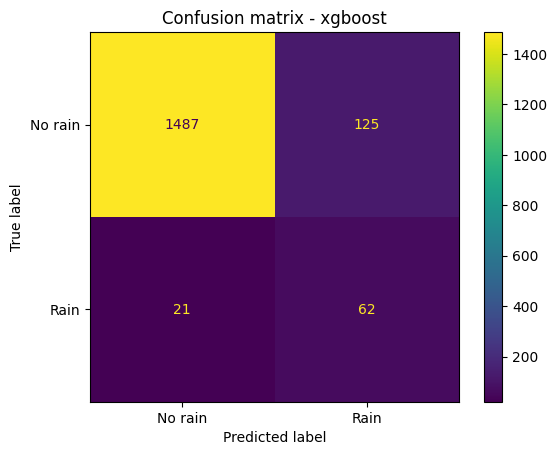

In [24]:
display_plot = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["No rain", "Rain"]
)

display_plot.plot()
plt.title(f"Confusion matrix - {best_model_name}")
plt.show()

# Inference

In [25]:
def load_saved_rain_model(save_folder):
    metadata_path = os.path.join(
        save_folder,
        "rain_model_metadata.json"
    )
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(
            "rain_model_metadata.json was not found. Rerun train_test_rain_models once so the best model is saved correctly."
        )
    with open(metadata_path, "r", encoding="utf-8") as file:
        metadata = json.load(file)
    model_path = os.path.join(
        save_folder,
        metadata["model_filename"]
    )
    preprocessor_path = os.path.join(
        save_folder,
        metadata["preprocessor_filename"]
    )
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Saved model not found: {model_path}")
    if not os.path.exists(preprocessor_path):
        raise FileNotFoundError(f"Saved preprocessor not found: {preprocessor_path}")
    if metadata["best_model_kind"] == "keras":
        model = load_model(model_path, compile=False)
    else:
        model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)
    return {
        "model": model,
        "model_kind": metadata["best_model_kind"],
        "model_name": metadata["best_model_name"],
        "preprocessor": preprocessor,
        "feature_columns": metadata["feature_columns"]
    }

def prepare_rain_inference_features(input_frame, feature_columns):
    frame = add_time_features(input_frame)
    for column in feature_columns:
        if column not in frame.columns:
            frame[column] = np.nan
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    return frame[feature_columns]

def predict_probability_from_model(model, model_kind, feature_values):
    if model_kind == "keras":
        sequence_values = make_sequence_features(feature_values)
        return model.predict(sequence_values, verbose=0).ravel()
    if hasattr(model, "predict_proba"):
        return model.predict_proba(feature_values)[:, 1]
    if hasattr(model, "decision_function"):
        score_values = model.decision_function(feature_values)
        return 1 / (1 + np.exp(-score_values))
    return model.predict(feature_values).astype(float)

def infer_rain_dataframe(input_frame, save_folder):
    saved_model = load_saved_rain_model(save_folder)
    preprocessor = saved_model["preprocessor"]
    model = saved_model["model"]
    feature_columns = saved_model["feature_columns"]
    model_kind = saved_model["model_kind"]
    raw_features = prepare_rain_inference_features(input_frame, feature_columns)
    feature_values = preprocessor.transform(raw_features)
    rain_probability = predict_probability_from_model(
        model,
        model_kind,
        feature_values
    )
    prediction = (rain_probability >= 0.50).astype(int)
    output_columns = [
        "dh_utc",
        "temperature",
        "pression",
        "humidite",
        "point_de_rosee",
        "vent_moyen",
        "vent_direction",
        "pluie_1h"
    ]
    available_output_columns = [
        column for column in output_columns
        if column in input_frame.columns
    ]
    output_frame = input_frame[available_output_columns].copy()
    output_frame["rain_probability"] = rain_probability
    output_frame["predicted_rain"] = prediction
    output_frame["prediction_label"] = np.where(prediction == 1, "rain", "no_rain")
    output_frame["model_used"] = saved_model["model_name"]
    return output_frame

def infer_random_rain_rows(input_frame, save_folder, sample_size=5, random_state=42):
    sample_frame = input_frame.sample(
        n=min(sample_size, len(input_frame)),
        random_state=random_state
    )
    return infer_rain_dataframe(sample_frame, save_folder)

In [26]:
prediction_frame = infer_random_rain_rows(df, save_folder, sample_size=5)
display(prediction_frame)

,dh_utc,temperature,pression,humidite,point_de_rosee,vent_moyen,vent_direction,pluie_1h,rain_probability,predicted_rain,prediction_label,model_used
47646,2026-04-18 05:20:00+00:00,13.4,1016.3,76.0,9.4,0.0,168.0,<NA>,0.016108,0,no_rain,xgboost
44685,2026-03-28 11:10:00+00:00,10.7,1020.0,62.0,3.3,0.0,167.0,<NA>,0.002381,0,no_rain,xgboost
25082,2025-11-06 08:30:00+00:00,<NA>,1004.7,<NA>,<NA>,<NA>,<NA>,<NA>,0.028921,0,no_rain,xgboost
39623,2026-02-20 23:20:00+00:00,11.5,1018.9,85.0,8.9,3.2,134.0,<NA>,0.057308,0,no_rain,xgboost
34456,2026-01-15 18:30:00+00:00,12.7,1000.8,75.0,8.3,4.8,223.0,<NA>,0.009169,0,no_rain,xgboost


# Prediction pour Nouveau Jours

In [27]:
def prepare_new_rain_features(input_frame, feature_columns):
    frame = input_frame.copy()
    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    if "dh_utc" not in frame.columns:
        raise ValueError("dh_utc is required to visualize predictions by day.")
    frame["dh_utc"] = pd.to_datetime(
        frame["dh_utc"],
        errors="coerce",
        utc=True
    )
    frame = add_time_features(frame)
    for column in feature_columns:
        if column not in frame.columns:
            frame[column] = np.nan
    feature_frame = frame[feature_columns].copy()
    for column in feature_columns:
        feature_frame[column] = pd.to_numeric(
            feature_frame[column],
            errors="coerce"
        )
    return frame, feature_frame

def get_rain_probability_from_model(model_kind, model, features):
    if model_kind == "keras":
        sequence_features = make_sequence_features(features)
        probability = model.predict(
            sequence_features,
            verbose=0
        ).ravel()
        return probability
    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(features)[:, 1]
        return probability
    if hasattr(model, "decision_function"):
        score = model.decision_function(features)
        score = np.clip(score, -30, 30)
        probability = 1 / (1 + np.exp(-score))
        return probability
    prediction = model.predict(features).astype(int)
    return prediction.astype(float)

def predict_new_rain_dataframe(input_frame, save_folder):
    saved_model = load_saved_rain_model(save_folder)
    prediction_frame, feature_frame = prepare_new_rain_features(
        input_frame,
        saved_model["feature_columns"]
    )
    transformed_features = saved_model["preprocessor"].transform(feature_frame)
    probability = get_rain_probability_from_model(
        saved_model["model_kind"],
        saved_model["model"],
        transformed_features
    )
    prediction_frame["rain_probability"] = probability
    prediction_frame["rain_prediction"] = (
        prediction_frame["rain_probability"] >= 0.50
    ).astype(int)
    prediction_frame["loaded_model_name"] = saved_model["model_name"]
    prediction_frame["loaded_model_kind"] = saved_model["model_kind"]
    return prediction_frame

def visualize_new_rain_days(input_frame, save_folder, day_count=6):
    prediction_frame = predict_new_rain_dataframe(
        input_frame,
        save_folder
    )
    prediction_frame["prediction_date"] = prediction_frame["dh_utc"].dt.date
    selected_dates = sorted(
        prediction_frame["prediction_date"].dropna().unique()
    )[:day_count]
    prediction_frame = prediction_frame[
        prediction_frame["prediction_date"].isin(selected_dates)
    ].copy()
    daily_prediction_frame = (
        prediction_frame
        .groupby("prediction_date")
        .agg(
            mean_rain_probability=("rain_probability", "mean"),
            max_rain_probability=("rain_probability", "max"),
            rainy_rows=("rain_prediction", "sum"),
            total_rows=("rain_prediction", "size")
        )
        .reset_index()
    )
    daily_prediction_frame["rain_prediction"] = (
        daily_prediction_frame["max_rain_probability"] >= 0.50
    ).astype(int)
    plt.figure(figsize=(10, 5))
    plt.plot(
        daily_prediction_frame["prediction_date"].astype(str),
        daily_prediction_frame["max_rain_probability"],
        marker="o",
        label="Daily max rain probability"
    )
    plt.plot(
        daily_prediction_frame["prediction_date"].astype(str),
        daily_prediction_frame["mean_rain_probability"],
        marker="o",
        label="Daily mean rain probability"
    )
    plt.axhline(
        0.50,
        linestyle="--",
        label="Decision threshold"
    )
    plt.xlabel("Date")
    plt.ylabel("Rain probability")
    plt.title("Rain prediction loaded from saved model")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return prediction_frame, daily_prediction_frame

In [28]:
metrics_frame = train_test_rain_models(df, save_folder)
display(metrics_frame)

,model,train_accuracy,test_accuracy,train_f1,test_f1,train_precision,test_precision,train_recall,test_recall
0,xgboost,0.9451,0.9139,0.6416,0.4593,0.4723,0.3316,1.0000,0.7470
1,rbf_svm,0.8599,0.8407,0.4010,0.3382,0.2538,0.2123,0.9550,0.8313
2,lstm_gru,0.8386,0.8265,0.2350,0.2097,0.1531,0.1349,0.5045,0.4699
3,linear_svm,0.8178,0.8059,0.3299,0.3015,0.2013,0.1830,0.9129,0.8554
4,lstm_dropout_lstm,0.7903,0.7870,0.2135,0.1888,0.1308,0.1160,0.5796,0.5060
5,attention_bilstm,0.7720,0.7605,0.2120,0.1815,0.1277,0.1090,0.6246,0.5422


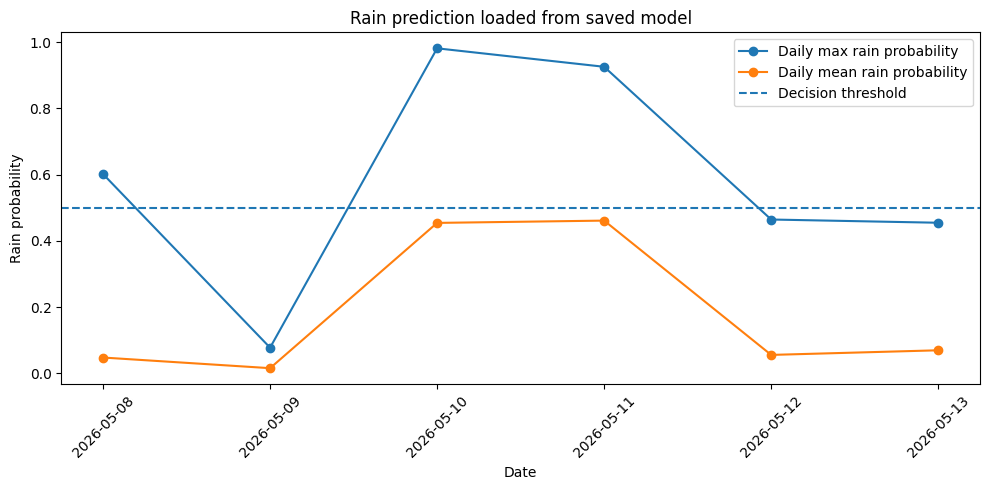

,prediction_date,mean_rain_probability,max_rain_probability,rainy_rows,total_rows,rain_prediction
0,2026-05-08,0.047430,0.601882,5,142,1
1,2026-05-09,0.015285,0.077241,0,144,0
2,2026-05-10,0.454258,0.981745,68,144,1
3,2026-05-11,0.461176,0.925974,70,144,1
4,2026-05-12,0.055373,0.464465,0,140,0
5,2026-05-13,0.069314,0.454724,0,87,0


In [29]:
latest_weather_frame = df.copy()
latest_weather_frame["dh_utc"] = pd.to_datetime(
    latest_weather_frame["dh_utc"],
    errors="coerce",
    utc=True
)

latest_dates = sorted(
    latest_weather_frame["dh_utc"].dt.date.dropna().unique()
)[-6:]

future_weather_frame = latest_weather_frame[
    latest_weather_frame["dh_utc"].dt.date.isin(latest_dates)
].copy()

prediction_frame, daily_prediction_frame = visualize_new_rain_days(
    future_weather_frame,
    save_folder,
    day_count=6
)

display(daily_prediction_frame)

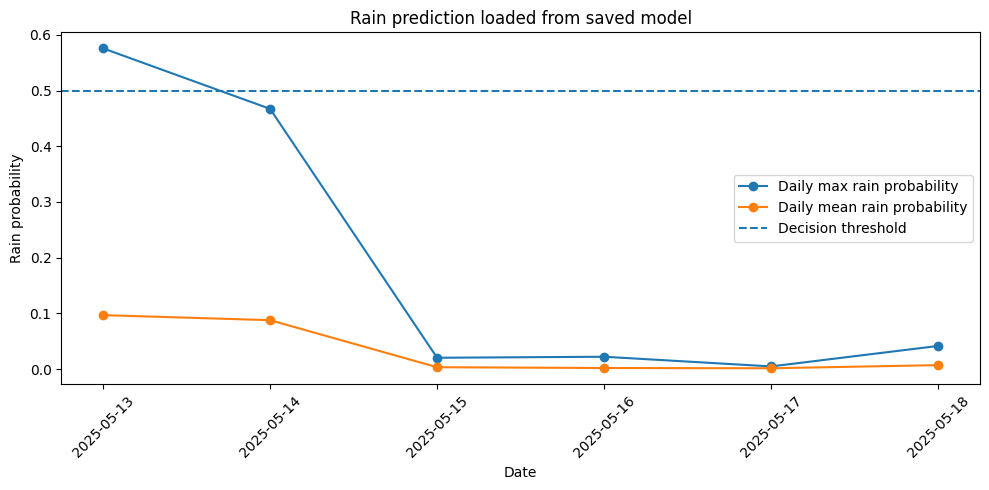

,prediction_date,mean_rain_probability,max_rain_probability,rainy_rows,total_rows,rain_prediction
0,2025-05-13,0.096937,0.575696,4,144,1
1,2025-05-14,0.087932,0.467081,0,144,0
2,2025-05-15,0.003544,0.020487,0,144,0
3,2025-05-16,0.002096,0.022313,0,144,0
4,2025-05-17,0.001655,0.004953,0,144,0
5,2025-05-18,0.007281,0.041728,0,144,0


In [30]:
prediction_frame, daily_prediction_frame = visualize_new_rain_days(
    df,
    save_folder,
    day_count=6
)

display(daily_prediction_frame)